# ADSP 32018 IP01 Next-Gen NLP: Transformers, LLMs and AgenticAI in Practice - Final Project

## Part 1: Data Loading & Inspection (Audit)

**Objective of this notebook:**
- Profile the news dataset quality before downstream NLP tasks.
- Produce concrete filtering recommendations backed by counts.
- Save reusable audit artifacts for later notebooks.

**Plan:**
- Load the parquet dataset and establish output paths.
- Audit schema, missingness, string lengths, duplicates, and date coverage.
- Flag likely crawl-noise rows (boilerplate, HTML artifacts, low-content text).
- Export summaries to `artifacts/data_audit/` for traceability.

## 0. Imports & Environment Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from urllib.parse import urlparse

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## 1. Dataset Loading & Basic Inspection

### 1.1 Load the Dataset

In this step, we create a local data directory, load the project parquet file, and cache a local copy so later notebooks can reuse the same input without downloading it again. This gives us the working dataframe `df` that will be audited throughout the notebook. We also print the overall row and column counts as a first sanity check on dataset size.

In [2]:
DATA_SAVE_DIR = Path("data/raw")
DATA_SAVE_DIR.mkdir(parents=True, exist_ok=True)

if not (DATA_SAVE_DIR / "news_final_project.parquet").exists():
    print("Downloading data...")
    df = pd.read_parquet("https://storage.googleapis.com/msca-bdp-data-open/news_final_project/news_final_project.parquet", engine="pyarrow")
    print("Data downloaded successfully.")
    df.to_parquet(DATA_SAVE_DIR / "news_final_project.parquet", engine="pyarrow")
else:
    df = pd.read_parquet(DATA_SAVE_DIR / "news_final_project.parquet", engine="pyarrow")
    print("Data loaded.")

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")

Data downloaded successfully.
Rows: 199,989 | Columns: 5


### 1.2 Inspect the Schema and Column Types

After loading the dataset, we inspect the dataframe schema to verify the available columns, their data types, and the number of non-null values. This is a lightweight structural audit that helps confirm whether the dataset matches expectations before moving into content-level checks.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199989 entries, 0 to 199988
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       199989 non-null  object
 1   date      199989 non-null  object
 2   language  199989 non-null  object
 3   title     199989 non-null  object
 4   text      199989 non-null  object
dtypes: object(5)
memory usage: 7.6+ MB


### 1.3 Audit Missing Values by Column

This section summarizes null counts and missing-value percentages for every column. The resulting table and bar chart help identify whether important fields such as title, text, URL, date, or language have substantial missingness that could affect downstream preprocessing and modeling.

,null_count,null_pct
url,0,0.0
date,0,0.0
language,0,0.0
title,0,0.0
text,0,0.0


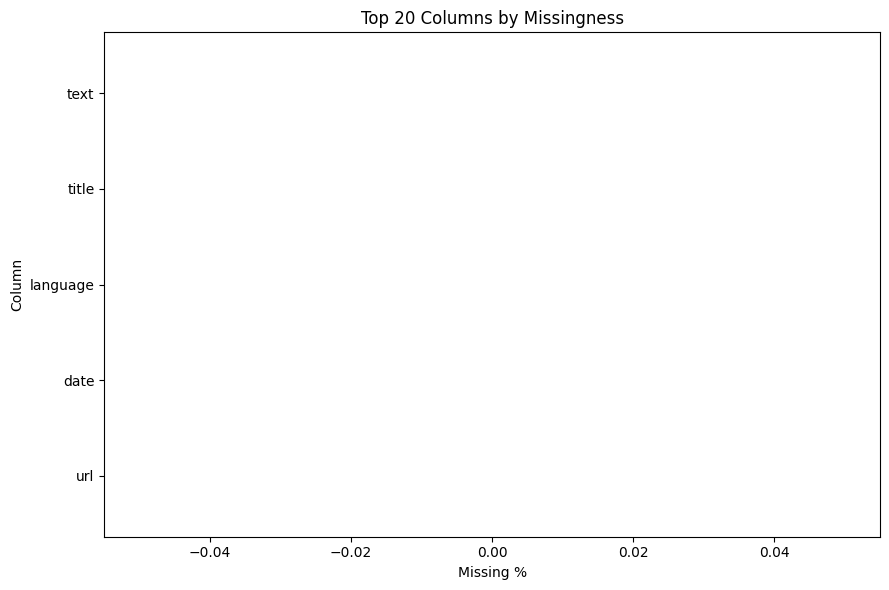

In [5]:
missing_df = (
    df.isna()
    .sum()
    .rename("null_count")
    .to_frame()
    .assign(null_pct=lambda x: (x["null_count"] / len(df) * 100).round(2))
    .sort_values("null_pct", ascending=False)
)

display(missing_df)

top_missing = missing_df.sort_values("null_pct", ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_missing.index, top_missing["null_pct"])
ax.set_title("Top 20 Columns by Missingness")
ax.set_xlabel("Missing %")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

### 1.4 Define Key Columns and Profile String Fields

Here, we explicitly define the core columns used in the rest of the project and compute lightweight text statistics for every string-like column. The output helps compare fields in terms of average length, token counts, and empty-string rates, which is useful for deciding which columns deserve further cleaning or quality checks.

In [6]:
text_col = "text"
title_col = "title"
url_col = "url"
date_col = "date"
lang_col = "language"
string_cols = [
    c
    for c in df.columns
    if pd.api.types.is_string_dtype(df[c]) or df[c].dtype == object
]

print("Key columns:")
print({"text_col": text_col, "title_col": title_col, "url_col": url_col, "date_col": date_col})

text_profile_rows = []
for col in string_cols:
    s = df[col].fillna("").astype(str)
    char_len = s.str.len()
    token_len = s.str.split().str.len()
    text_profile_rows.append(
        {
            "column": col,
            "avg_chars": round(char_len.mean(), 2),
            "p50_chars": int(char_len.quantile(0.50)),
            "p90_chars": int(char_len.quantile(0.90)),
            "avg_tokens": round(token_len.mean(), 2),
            "empty_pct": round((s.str.strip() == "").mean() * 100, 2),
        }
    )

text_profile_df = pd.DataFrame(text_profile_rows).sort_values("avg_chars", ascending=False)
display(text_profile_df)

Key columns:
{'text_col': 'text', 'title_col': 'title', 'url_col': 'url', 'date_col': 'date'}


,column,avg_chars,p50_chars,p90_chars,avg_tokens,empty_pct
4,text,9098.77,7622,15766,1231.99,0.0
0,url,113.29,111,161,1.00,0.0
3,title,86.64,82,123,13.87,0.0
1,date,10.00,10,10,1.00,0.0
2,language,2.00,2,2,1.00,0.0


### 1.5 Inspect the Overall Text-Length Distribution

This block focuses on the main article text field and visualizes the character-length distribution across the dataset. The goal is to see whether the corpus contains a wide mix of short snippets, medium-length articles, and extremely long crawl outputs, all of which matter for later NLP preprocessing choices.

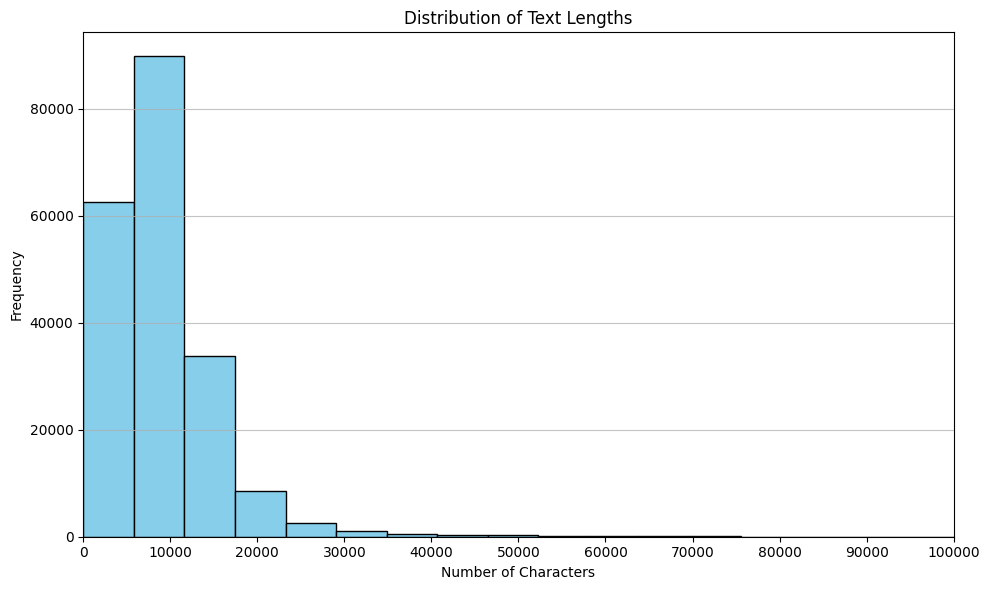

In [7]:
text_lengths = df[text_col].fillna("").astype(str).str.len()
plt.figure(figsize=(10, 6))
plt.hist(text_lengths, bins=100, color="skyblue", edgecolor="black")
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.xlim(0, 100000)
plt.xticks(np.arange(0, 100001, 10000))
plt.grid(axis="y", alpha=0.75)
plt.tight_layout()
plt.show()

### 1.6 Compare Text Length Across High-Volume Domains

Different websites often produce very different crawl patterns. In this section, we extract article domains from the URL field, identify the most common sources, and compare token-length distributions across those top domains. This helps reveal whether some publishers systematically contribute shorter snippets, longer pages, or noisier crawl outputs.

/var/folders/0y/00m4bccd65z2kg9pf2pb_94h0000gn/T/ipykernel_44389/2126997063.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top_domains, showfliers=False)


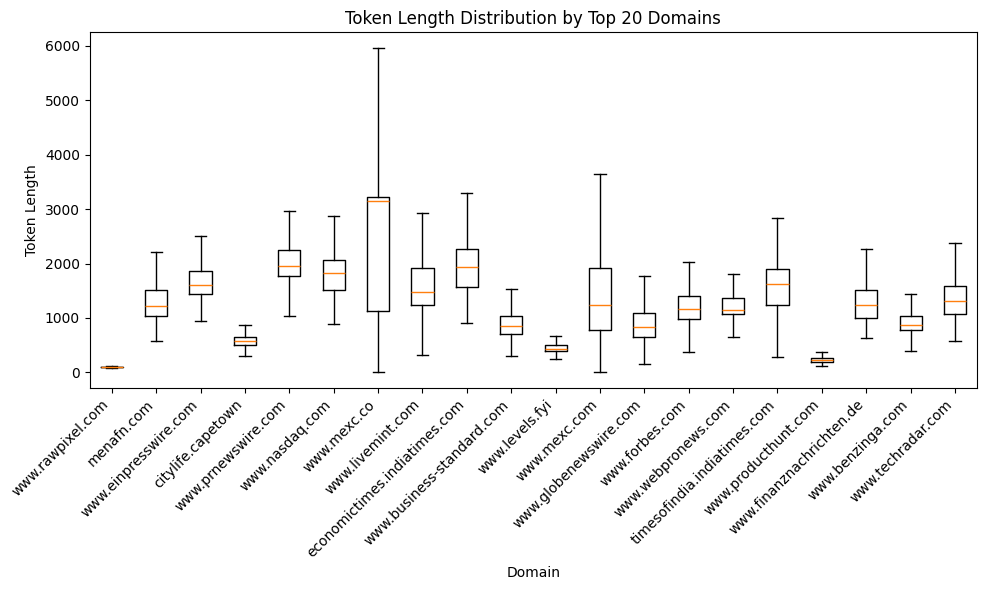

In [8]:
df["domain"] = (
    df[url_col]
    .fillna("")
    .astype(str)
    .map(lambda u: urlparse(u).netloc.lower())
)

top_domains = df["domain"].value_counts().head(20).index.tolist()

df_top = df.loc[df["domain"].isin(top_domains), [text_col, "domain"]].copy()
df_top["token_len"] = df_top[text_col].fillna("").astype(str).str.split().str.len()

df_top["domain"] = pd.Categorical(df_top["domain"], categories=top_domains, ordered=True)

data = [df_top.loc[df_top["domain"] == d, "token_len"].to_numpy() for d in top_domains]

plt.figure(figsize=(10, 6))
plt.boxplot(data, labels=top_domains, showfliers=False)
plt.title("Token Length Distribution by Top 20 Domains")
plt.xlabel("Domain")
plt.ylabel("Token Length")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 1.7 Read a Small Sample of Raw Records

Before defining formal quality rules, it is useful to look directly at a few examples from the raw dataset. This quick qualitative check gives a better sense of how clean the article titles and texts look in practice, and it helps ground the later filtering logic in actual observed records.

In [9]:
sample_df = df[[title_col, text_col]].dropna().sample(5, random_state=42)
for idx, row in sample_df.iterrows ():
    print(f"Sample {idx}:")
    print(f"Title: {row[title_col]}")
    print(f"Text: {row[text_col]}")
    print("-" * 80)

Sample 129081:
Title: Researchers have developed an AI tool that can closely imitate your handwriting style – Cedar News English
Text:   Researchers have developed an AI tool that can closely imitate your handwriting style – Cedar News English
      

Skip to contentThu. Jan 18th, 2024                         

  
HomeBreakingLebanonNewsPoliticsCrimesVideoEntertainmentAR
  
 

News
 
Researchers have developed an AI tool that can closely imitate your handwriting style
 By

Jan 16, 2024

closely, developed, handwriting, imitate, researchers, style:

   The Mohamad Bin Zayed University of Artificial Intelligence claims to be the first AI university in the world.   iStock   A team of inventors have received a patent from the US for an AI tool that can copy people’s handwriting.It’s able to produce text based off just a few paragraphs of a person’s original handwriting. However, the team said they’re being cautious because it can be misused for forgery.   AI can clone your voice, and creat

## 2. Duplication and Temporal Coverage

### 2.1 Check for Duplicate Rows, URLs, and Normalized Text

This section measures duplication at multiple levels: exact duplicated rows, repeated URLs, and repeated article text after basic normalization. These summaries help estimate how much redundancy may exist in the raw crawl and whether deduplication should be part of the cleaning pipeline.

In [10]:
duplicate_summary = {}
duplicate_summary["exact_row_duplicates"] = int(df.duplicated().sum())

url_series = df[url_col].fillna("").astype(str).str.strip().str.lower()
duplicate_summary["duplicate_urls"] = int(url_series.duplicated().sum())

normalized_text = (
    df[text_col]
    .fillna("")
    .astype(str)
    .str.replace(r"<[^>]+>", " ", regex=True)
    .str.replace(r"https?://\S+|www\.\S+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.lower()
)

duplicate_summary["duplicate_normalized_text"] = int(normalized_text.duplicated().sum())

duplicate_df = pd.DataFrame(
    {
        "metric": list(duplicate_summary.keys()),
        "rows_flagged": list(duplicate_summary.values()),
    }
)

duplicate_df["pct_of_dataset"] = (duplicate_df["rows_flagged"] / len(df) * 100).round(2)
display(duplicate_df)

,metric,rows_flagged,pct_of_dataset
0,exact_row_duplicates,0,0.00
1,duplicate_urls,2,0.00
2,duplicate_normalized_text,511,0.26


### 2.2 Audit Date Parsing Quality

Since later analyses depend on article timing, we convert the raw date field to a parsed timestamp and summarize parse success, earliest date, and latest date. This shows whether temporal information is broadly usable and whether the observed date range matches expectations for the project dataset.

In [11]:
parsed_dates = pd.to_datetime(df[date_col], errors="coerce", utc=True)
date_summary = pd.DataFrame(
    {
        "metric": ["parse_success_pct", "min_date", "max_date"],
        "value": [
            round(parsed_dates.notna().mean() * 100, 2),
            parsed_dates.min(),
            parsed_dates.max(),
        ],
    }
)
display(date_summary)

,metric,value
0,parse_success_pct,100.0
1,min_date,2022-01-01 00:00:00+00:00
2,max_date,2026-02-10 00:00:00+00:00


### 2.3 Visualize Article Volume Over Time

Once the dates are parsed, we aggregate article counts by month and plot the resulting timeline. This makes it easier to see how coverage changes over time and whether there are obvious spikes, gaps, or crawl periods that could influence later topic, entity, or trend analyses.

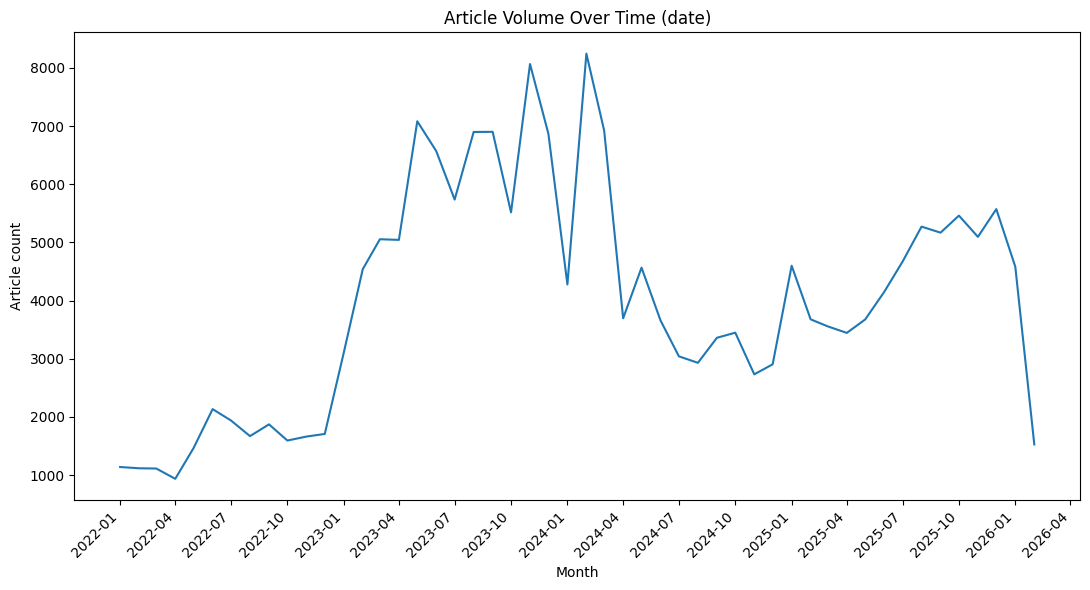

In [12]:
monthly_counts = (
    parsed_dates.dropna()
    .dt.tz_localize(None)
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

monthly_counts_dt = monthly_counts.copy()
monthly_counts_dt.index = monthly_counts_dt.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(monthly_counts_dt.index, monthly_counts_dt.values)

ax.set_title(f"Article Volume Over Time ({date_col})")
ax.set_xlabel("Month")
ax.set_ylabel("Article count")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 3. Text Quality Flags and Filtering Recommendations

### 3.1 Build Heuristic Quality Flags

In this section, we create a set of simple, interpretable heuristics to flag records that may be poor candidates for downstream NLP analysis. These rules capture patterns such as empty text, very short content, HTML artifacts, visible URLs, boilerplate language, and unusually low alphabetic content. We then combine these rules into a broader `drop_candidate` flag that serves as an initial filtering suggestion rather than a final irreversible decision.

In [13]:
text_series = df[text_col].fillna("").astype(str)
token_counts = text_series.str.split().str.len()
char_counts = text_series.str.len().replace(0, np.nan)
alpha_ratio = text_series.str.count(r"[A-Za-z]") / char_counts

flags_df = pd.DataFrame(
    {
        "is_empty": text_series.str.strip().eq(""),
        "too_short_lt_40_tokens": token_counts.lt(40),
        "has_html_tags": text_series.str.contains(r"<[^>]+>", regex=True),
        "has_url": text_series.str.contains(r"https?://\S+|www\.\S+", regex=True),
        "boilerplate_term": text_series.str.contains(
            r"cookie policy|terms of service|all rights reserved|subscribe|sign up|newsletter|advertisement",
            case=False,
            regex=True,
        ),
        "low_alpha_ratio_lt_0.65": alpha_ratio.lt(0.65),
    }
)

flags_df["drop_candidate"] = (
    flags_df["is_empty"]
    | (flags_df["too_short_lt_40_tokens"] & flags_df["low_alpha_ratio_lt_0.65"])
    | (flags_df["has_html_tags"] & flags_df["boilerplate_term"])
)

quality_summary_df = pd.DataFrame(
    {
        "rule": flags_df.columns,
        "rows_flagged": [int(flags_df[c].sum()) for c in flags_df.columns],
    }
)
quality_summary_df["pct_of_dataset"] = (quality_summary_df["rows_flagged"] / len(df) * 100).round(2)
display(quality_summary_df.sort_values("pct_of_dataset", ascending=False))

,rule,rows_flagged,pct_of_dataset
4,boilerplate_term,174260,87.13
3,has_url,64400,32.20
5,low_alpha_ratio_lt_0.65,14421,7.21
2,has_html_tags,2444,1.22
6,drop_candidate,2092,1.05
1,too_short_lt_40_tokens,1025,0.51
0,is_empty,0,0.00


### 3.2 Visualize the Impact of Each Quality Rule

After constructing the rule-based flags, we summarize how many rows are affected by each one and visualize their relative impact. This provides an immediate sense of which issues are common in the dataset and which filters would have the largest practical effect if applied.

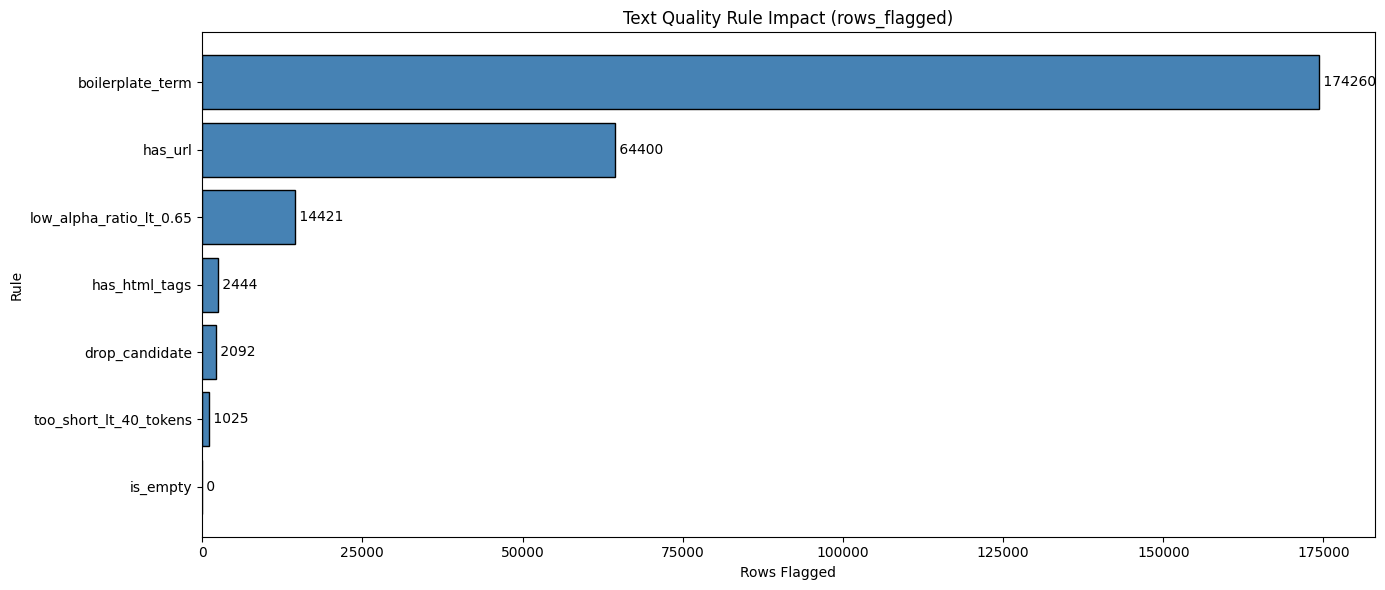

In [ ]:
# Horizontal bar chart for rule impact in quality_summary_df
plot_col = "rows_flagged"

plot_df = quality_summary_df.sort_values(plot_col, ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(plot_df["rule"], plot_df[plot_col], color="steelblue", edgecolor="black")

ax.set_title(f"Text Quality Rule Impact ({plot_col})")
ax.set_xlabel(plot_col.replace("_", " ").title())
ax.set_ylabel("Rule")

# value labels
for bar, val in zip(bars, plot_df[plot_col]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f" {val}", va="center")

plt.tight_layout()
plt.show()

### 3.3 Examine Overlap Between Quality Rules

Quality problems often co-occur. This block measures pairwise overlap and Jaccard similarity across the base flag columns, then visualizes the results as heatmaps. The purpose is to understand whether different heuristics are capturing distinct kinds of noise or repeatedly flagging the same subset of problematic records.

,is_empty,too_short_lt_40_tokens,has_html_tags,has_url,boilerplate_term,low_alpha_ratio_lt_0.65
is_empty,0,0,0,0,0,0
too_short_lt_40_tokens,0,1025,0,18,29,29
has_html_tags,0,0,2444,1183,2063,332
has_url,0,18,1183,64400,56104,2691
boilerplate_term,0,29,2063,56104,174260,13234
low_alpha_ratio_lt_0.65,0,29,332,2691,13234,14421


,is_empty,too_short_lt_40_tokens,has_html_tags,has_url,boilerplate_term,low_alpha_ratio_lt_0.65
is_empty,0.0,0.000,0.000,0.000,0.000,0.000
too_short_lt_40_tokens,0.0,1.000,0.000,0.000,0.000,0.002
has_html_tags,0.0,0.000,1.000,0.018,0.012,0.020
has_url,0.0,0.000,0.018,1.000,0.307,0.035
boilerplate_term,0.0,0.000,0.012,0.307,1.000,0.075
low_alpha_ratio_lt_0.65,0.0,0.002,0.020,0.035,0.075,1.000


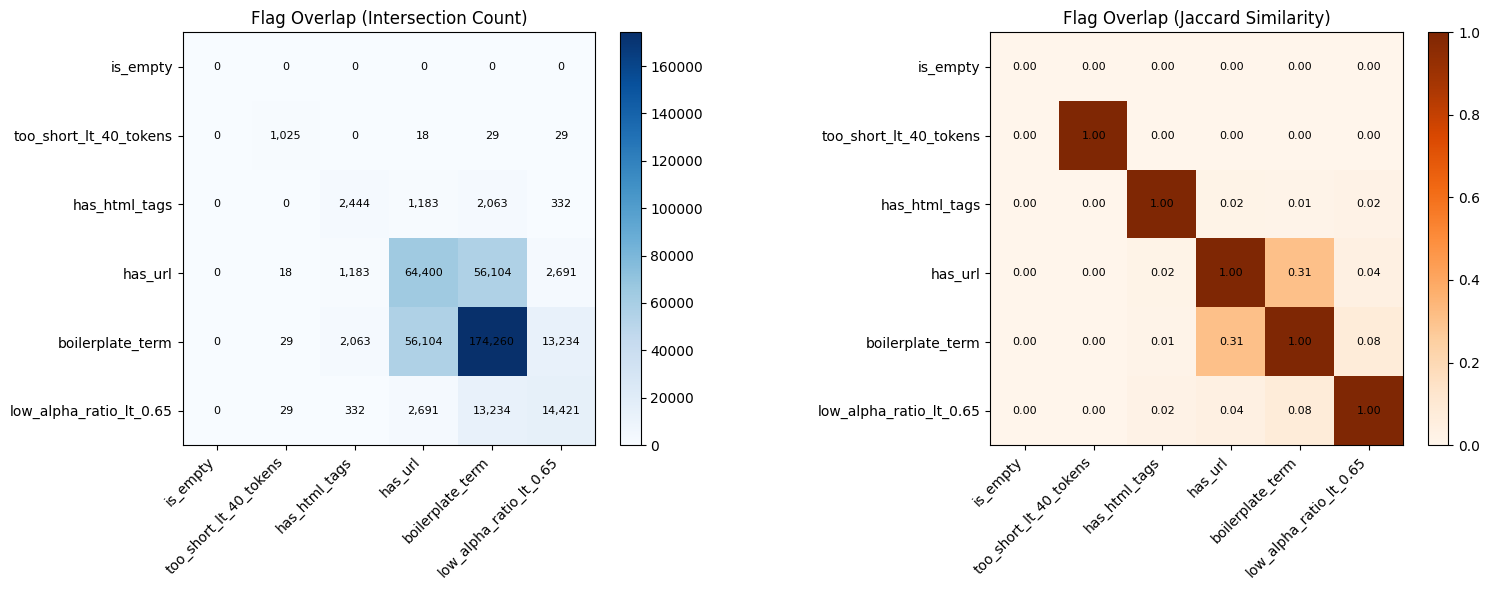

In [15]:
base_flag_cols = [c for c in flags_df.columns if c != "drop_candidate"]
flag_mat = flags_df[base_flag_cols].astype(bool)

overlap_counts = pd.DataFrame(
    {
        c1: {c2: int((flag_mat[c1] & flag_mat[c2]).sum()) for c2 in base_flag_cols}
        for c1 in base_flag_cols
    }
)

overlap_jaccard = pd.DataFrame(
    {
        c1: {
            c2: (
                (flag_mat[c1] & flag_mat[c2]).sum() / (flag_mat[c1] | flag_mat[c2]).sum()
                if (flag_mat[c1] | flag_mat[c2]).sum() > 0
                else 0.0
            )
            for c2 in base_flag_cols
        }
        for c1 in base_flag_cols
    }
)

display(overlap_counts)
display(overlap_jaccard.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: raw overlap counts
im0 = axes[0].imshow(overlap_counts.values, cmap="Blues")
axes[0].set_title("Flag Overlap (Intersection Count)")
axes[0].set_xticks(range(len(base_flag_cols)))
axes[0].set_yticks(range(len(base_flag_cols)))
axes[0].set_xticklabels(base_flag_cols, rotation=45, ha="right")
axes[0].set_yticklabels(base_flag_cols)
for i in range(len(base_flag_cols)):
    for j in range(len(base_flag_cols)):
        axes[0].text(j, i, f"{overlap_counts.values[i, j]:,}", ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Heatmap 2: Jaccard similarity
im1 = axes[1].imshow(overlap_jaccard.values, cmap="Oranges", vmin=0, vmax=1)
axes[1].set_title("Flag Overlap (Jaccard Similarity)")
axes[1].set_xticks(range(len(base_flag_cols)))
axes[1].set_yticks(range(len(base_flag_cols)))
axes[1].set_xticklabels(base_flag_cols, rotation=45, ha="right")
axes[1].set_yticklabels(base_flag_cols)
for i in range(len(base_flag_cols)):
    for j in range(len(base_flag_cols)):
        axes[1].text(j, i, f"{overlap_jaccard.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### 3.4 Review Example Drop Candidates

Quantitative summaries are helpful, but they are easier to trust when paired with real examples. This section prints a small sample of rows flagged as `drop_candidate` so we can qualitatively inspect whether the heuristic rules are identifying genuinely noisy or low-value crawl outputs.

In [31]:
drop_candidate_samples = df.loc[flags_df["drop_candidate"], [title_col, text_col]].dropna().sample(5, random_state=42)
for idx, row in drop_candidate_samples.iterrows():
    print(f"Sample {idx}:")
    print(f"Title: {row[title_col]}")
    print(f"Text: {row[text_col]}...")
    print("-" * 80)

Sample 115810:
Title: The Biden administration wants to put AI to the test for cybersecurity - The Washington Post
Text: The Biden administration wants to put AI to the test for cybersecurity - The Washington PostAccessibility statementSkip to main contentDemocracy Dies in DarknessSign inThe Washington PostDemocracy Dies in DarknessThe Cybersecurity 202A newsletter briefing on cybersecurity news and policy.Subscribe to the newsletterAddThe Biden administration wants to put AI to the test for cybersecurityAnalysis by  Tim Starkswith research by David DiMolfettaAugust 10, 2023 at 7:12 a.m. EDTA newsletter briefing on cybersecurity news and policy.AddSign upfor The Cybersecurity 202 newsletterShareComment on this storyCommentWelcome to the Cybersecurity 202! We’re off on Friday and Monday, so see you next on Tuesday.Was this forwarded to you? Sign up here.WpGet the full experience.Choose your planArrowRightBelow: Northern Ireland police officers’ data is accidentally exposed, and a White 

### 3.5 Interpret the Example Drop Candidates

These notes document the qualitative judgment from the sampled flagged records. Rather than treating the filtering rules as purely automatic, this markdown explains why the examples do or do not align with the intended definition of low-quality or boilerplate-heavy pages.

- The Washington Post example contains a large amount of navigation, newsletter signup, “Advertisement”, and site footer content mixed with the main article. This is a realistic case of web-crawl boilerplate dominating the text, so flagging it as a drop candidate is consistent with the intent of the rules.
- The Daily Mail example is an extreme boilerplate-heavy page with large menus, repeated headlines, and ad blocks. This is strongly aligned with the drop-candidate goal.
- The Nasdaq example includes extensive site navigation and “Market Activity” scaffolding before the article body. This suggests that boilerplate can be present even when the article itself is relevant, so the filtering rules should avoid dropping too aggressively.
- The DVIDS page is largely structural content around a video page, which may be irrelevant for downstream industry/company impact analysis unless the project explicitly wants to include non-article pages.

### 3.6 Summarize Recommended Filtering Rules

Here, we convert the earlier diagnostics into a concise recommendation table. The goal is to translate audit findings into concrete next-step actions, such as dropping empty text rows, removing low-information records, and deduplicating repeated content or URLs.

In [16]:
rule_rows = [
    (
        "Drop rows with empty text",
        int(flags_df["is_empty"].sum()),
    ),
    (
        "Drop rows that are short and low-information (<40 tokens and low alpha ratio)",
        int((flags_df["too_short_lt_40_tokens"] & flags_df["low_alpha_ratio_lt_0.65"]).sum()),
    ),
    (
        "Drop likely boilerplate pages (HTML tags + boilerplate terms)",
        int((flags_df["has_html_tags"] & flags_df["boilerplate_term"]).sum()),
    ),
]

if url_col is not None:
    url_dupes = df[url_col].fillna("").astype(str).str.strip().str.lower().duplicated().sum()
    rule_rows.append(("Deduplicate by canonical URL", int(url_dupes)))

if normalized_text is not None:
    text_dupes = normalized_text.duplicated().sum()
    rule_rows.append(("Deduplicate by normalized text", int(text_dupes)))

recommendation_df = pd.DataFrame(rule_rows, columns=["recommended_filter", "rows_impacted"])
recommendation_df["pct_of_dataset"] = (recommendation_df["rows_impacted"] / len(df) * 100).round(2)
recommendation_df = recommendation_df.sort_values("rows_impacted", ascending=False)
display(recommendation_df)

,recommended_filter,rows_impacted,pct_of_dataset
2,Drop likely boilerplate pages (HTML tags + boi...,2063,1.03
4,Deduplicate by normalized text,511,0.26
1,Drop rows that are short and low-information (...,29,0.01
3,Deduplicate by canonical URL,2,0.00
0,Drop rows with empty text,0,0.00


### 3.7 Estimate the Effect of an Initial Filtering Pass

Finally, we apply a conservative first-pass keep mask to estimate how many rows would remain after dropping likely low-quality records and duplicate URLs. This gives a practical sense of how much the dataset would shrink under the proposed cleaning rules and prepares the project for downstream preprocessing notebooks.

In [17]:
keep_mask = ~flags_df["drop_candidate"]

if url_col is not None:
    canonical_url = df[url_col].fillna("").astype(str).str.strip().str.lower()
    keep_mask &= ~canonical_url.duplicated(keep="first")

rows_before = len(df)
rows_after = int(keep_mask.sum())
rows_removed = rows_before - rows_after
pct_removed = rows_removed / rows_before * 100

print(f"Rows before: {rows_before:,}")
print(f"Rows after initial quality filters: {rows_after:,}")
print(f"Rows removed: {rows_removed:,} ({pct_removed:.2f}%)")

Rows before: 199,989
Rows after initial quality filters: 197,895
Rows removed: 2,094 (1.05%)
